# 1.1 数据预处理与格式转换 - 测试版（决赛）

## 目标

本notebook用于加载2022世界杯决赛的追踪数据，并转换为MORPH项目的统一格式。

## 数据信息

- **比赛**: 2022世界杯决赛
- **对阵**: 阿根廷 vs 法国
- **gameID**: 10517
- **数据来源**: Gradient Sports Enhanced 2022 World Cup Dataset

## 输出格式

- **追踪数据**: Polars DataFrame (参考EFPI的KloppyPolarsDataset)
- **保存格式**: Parquet (高效压缩，快速读取)

## 1. 导入必要的库

In [1]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 数据处理
import polars as pl
import pandas as pd
import numpy as np

# Kloppy和unravelsports
import kloppy
from kloppy import pff
from unravel.soccer import KloppyPolarsDataset

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch

# 配置matplotlib中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'KaiTi', 'FangSong']
plt.rcParams['axes.unicode_minus'] = False

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pl.Config.set_tbl_rows(100)

print(f"Kloppy版本: {kloppy.__version__}")
print(f"Polars版本: {pl.__version__}")
print("✅ 库导入成功")

Kloppy版本: 3.17.0
Polars版本: 1.2.1
✅ 库导入成功


## 2. 设置数据路径

In [2]:
# 数据根目录
DATA_ROOT = Path(r"E:\JerryWu\Master\SoccerAnalytics\OpenData\TrackingData\Gradient Sports  Enhanced 2022 World Cup Dataset")

# 各类数据目录
TRACKING_DIR = DATA_ROOT / "Tracking Data"
METADATA_DIR = DATA_ROOT / "Metadata"
ROSTERS_DIR = DATA_ROOT / "Rosters"

# 决赛数据文件
FINAL_GAME_ID = "10517"
FINAL_TRACKING_FILE = TRACKING_DIR / f"{FINAL_GAME_ID}.jsonl.bz2"
FINAL_METADATA_FILE = METADATA_DIR / f"{FINAL_GAME_ID}.json"
FINAL_ROSTER_FILE = ROSTERS_DIR / f"{FINAL_GAME_ID}.json"

# 输出目录
OUTPUT_DIR = Path("../../data/morph_test")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 验证文件存在
print("检查数据文件...")
files_ok = True

if FINAL_TRACKING_FILE.exists():
    print(f"✅ 追踪数据: {FINAL_TRACKING_FILE.name} ({FINAL_TRACKING_FILE.stat().st_size / 1024 / 1024:.2f} MB)")
else:
    print(f"❌ 未找到追踪数据: {FINAL_TRACKING_FILE}")
    files_ok = False

if FINAL_METADATA_FILE.exists():
    print(f"✅ 元数据: {FINAL_METADATA_FILE.name}")
else:
    print(f"❌ 未找到元数据: {FINAL_METADATA_FILE}")
    files_ok = False

if FINAL_ROSTER_FILE.exists():
    print(f"✅ 阵容数据: {FINAL_ROSTER_FILE.name}")
else:
    print(f"❌ 未找到阵容数据: {FINAL_ROSTER_FILE}")
    files_ok = False

if not files_ok:
    print("\n⚠️  请检查数据路径是否正确")

检查数据文件...
✅ 追踪数据: 10517.jsonl.bz2 (63.56 MB)
✅ 元数据: 10517.json
✅ 阵容数据: 10517.json


## 3. 加载追踪数据

使用kloppy的PFF加载器加载数据。

**重要**: PFF格式需要三个文件：
- `meta_data`: 比赛元数据
- `roster_meta_data`: 球员阵容数据
- `raw_data`: 追踪数据

In [3]:
print("开始加载追踪数据...")
print("注意：首次加载可能需要几分钟时间")

try:
    # 使用PFF格式加载
    kloppy_dataset = pff.load_tracking(
        meta_data=str(FINAL_METADATA_FILE),
        roster_meta_data=str(FINAL_ROSTER_FILE),
        raw_data=str(FINAL_TRACKING_FILE),
        coordinates="secondspectrum",
        only_alive=True,
    )
    print("✅ 数据加载成功！")
    
except Exception as e:
    print(f"❌ 加载失败: {e}")
    print("\n错误详情:")
    import traceback
    traceback.print_exc()

开始加载追踪数据...
注意：首次加载可能需要几分钟时间
✅ 数据加载成功！


## 4. 检查数据基本信息

In [4]:
# 数据集基本信息
print("=" * 60)
print("数据集基本信息")
print("=" * 60)

# 元数据
metadata = kloppy_dataset.metadata
print(f"\n比赛ID: {metadata.game_id}")
print(f"帧率: {metadata.frame_rate} fps")
print(f"方向: {metadata.orientation}")
print(f"坐标系统: {metadata.coordinate_system}")

# 球场尺寸
pitch_dims = metadata.pitch_dimensions
print(f"\n球场尺寸:")
print(f"  长度: {pitch_dims.pitch_length}m")
print(f"  宽度: {pitch_dims.pitch_width}m")

# 球队信息
home_team, away_team = metadata.teams
print(f"\n主队: {home_team.name} (ID: {home_team.team_id})")
print(f"  球员数: {len(home_team.players)}")
print(f"客队: {away_team.name} (ID: {away_team.team_id})")
print(f"  球员数: {len(away_team.players)}")

# 数据帧信息
print(f"\n数据帧数: {len(kloppy_dataset.frames)}")
print(f"比赛时长: {len(kloppy_dataset.frames) / metadata.frame_rate / 60:.2f} 分钟")

数据集基本信息

比赛ID: 10517
帧率: 29.97 fps
方向: Orientation.HOME_AWAY
坐标系统: <kloppy.domain.models.common.SecondSpectrumCoordinateSystem object at 0x00000234FFF84050>

球场尺寸:
  长度: 105.0m
  宽度: 68.0m

主队: Argentina (ID: 364)
  球员数: 26
客队: France (ID: 363)
  球员数: 24

数据帧数: 130308
比赛时长: 72.47 分钟


## 5. 转换为MORPH统一格式

将kloppy数据集转换为Polars DataFrame格式（MORPH标准格式）。

In [5]:
print("开始转换为MORPH统一格式...")

try:
    dataset = KloppyPolarsDataset(
        kloppy_dataset=kloppy_dataset,
        ball_carrier_threshold=25.0,
        max_player_speed=12.0,
        max_ball_speed=28.0,
        max_player_acceleration=6.0,
        max_ball_acceleration=13.5,
        orient_ball_owning=False,  # 修复：不根据控球方翻转坐标，保持固定方向
        add_smoothing=True,
    )
    print("✅ 转换成功！")
    print(f"\n数据集: {dataset}")
    
except Exception as e:
    print(f"❌ 转换失败: {e}")
    import traceback
    traceback.print_exc()

开始转换为MORPH统一格式...
✅ 转换成功！

数据集: KloppyPolarsDataset(n_frames=129368)


## 6. 数据探索与验证

In [6]:
# 查看数据结构
print("数据列:")
print(dataset.data.columns)

print("\n数据形状:")
print(f"行数: {len(dataset.data):,}")
print(f"列数: {len(dataset.data.columns)}")

print("\n前5行数据:")
display(dataset.data.head())

数据列:
['period_id', 'timestamp', 'frame_id', 'ball_state', 'id', 'x', 'y', 'z', 'team_id', 'position_name', 'game_id', 'vx', 'vy', 'vz', 'v', 'ax', 'ay', 'az', 'a', 'ball_owning_team_id', 'is_ball_carrier']

数据形状:
行数: 2,966,182
列数: 21

前5行数据:


period_id,timestamp,frame_id,ball_state,id,x,y,z,team_id,position_name,game_id,vx,vy,vz,v,ax,ay,az,a,ball_owning_team_id,is_ball_carrier
i64,duration[μs],i64,str,str,f64,f64,f64,str,str,i32,f64,f64,f64,f64,f64,f64,f64,f64,str,bool
1,821µs,4630,"""alive""","""10715""",4.987,-1.993,0.0,"""364""","""ST""",10517,-0.522823,0.079386,0.0,0.528815,0.0,0.0,0.0,0.0,"""363""",false
1,821µs,4630,"""alive""","""11""",-18.172,3.632,0.0,"""364""","""LCB""",10517,-1.114241,-0.985899,0.0,1.487794,0.0,0.0,0.0,0.0,"""363""",false
1,821µs,4630,"""alive""","""113""",0.763,-18.099,0.0,"""363""","""ST""",10517,-2.287401,-0.437484,0.0,2.328862,0.0,0.0,0.0,0.0,"""363""",false
1,821µs,4630,"""alive""","""11856""",-6.252,3.173,0.0,"""364""","""CM""",10517,-1.145117,-1.007385,0.0,1.525161,0.0,0.0,0.0,0.0,"""363""",false
1,821µs,4630,"""alive""","""13222""",3.636,18.712,0.0,"""364""","""RB""",10517,-0.874427,-1.040521,0.0,1.359156,0.0,0.0,0.0,0.0,"""363""",false


In [7]:
# 数据统计
print("数据统计信息:")
print("=" * 60)

# 帧数统计
n_frames = dataset.data['frame_id'].n_unique()
print(f"\n总帧数: {n_frames:,}")

# 时期统计
periods = dataset.data['period_id'].unique().sort()
print(f"\n比赛时期: {periods.to_list()}")

for period in periods:
    period_data = dataset.data.filter(pl.col('period_id') == period)
    period_frames = period_data['frame_id'].n_unique()
    period_duration = period_frames / dataset.settings.frame_rate / 60
    print(f"  时期 {period}: {period_frames:,} 帧 ({period_duration:.2f} 分钟)")

# 球员统计
n_players = dataset.data.filter(pl.col('team_id') != 'ball')['id'].n_unique()
print(f"\n球员总数: {n_players}")

# 球队统计
teams = dataset.data.filter(pl.col('team_id') != 'ball')['team_id'].unique()
print(f"\n球队:")
for team_id in teams:
    team_players = dataset.data.filter(pl.col('team_id') == team_id)['id'].n_unique()
    print(f"  {team_id}: {team_players} 名球员")

数据统计信息:

总帧数: 129,368

比赛时期: [1, 2, 3, 4]
  时期 1: 50,084 帧 (27.85 分钟)
  时期 2: 50,077 帧 (27.85 分钟)
  时期 3: 16,456 帧 (9.15 分钟)
  时期 4: 12,751 帧 (7.09 分钟)

球员总数: 35

球队:
  364: 17 名球员
  363: 18 名球员


## 7. 数据质量检查

In [8]:
print("数据质量检查")
print("=" * 60)

# 检查缺失值
print("\n缺失值统计:")
null_counts = dataset.data.null_count()
has_nulls = False
for col in null_counts.columns:
    null_count = null_counts[col][0]
    if null_count > 0:
        has_nulls = True
        pct = null_count / len(dataset.data) * 100
        print(f"  {col}: {null_count:,} ({pct:.2f}%)")
if not has_nulls:
    print("  ✅ 无缺失值")

# 检查速度和加速度范围
print("\n速度统计 (m/s):")
speed_stats = dataset.data.filter(pl.col('team_id') != 'ball')['v'].describe()
print(speed_stats)

print("\n加速度统计 (m/s²):")
acc_stats = dataset.data.filter(pl.col('team_id') != 'ball')['a'].describe()
print(acc_stats)

# 检查坐标范围
print("\n坐标范围:")
x_range = dataset.data['x'].min(), dataset.data['x'].max()
y_range = dataset.data['y'].min(), dataset.data['y'].max()
print(f"  X: [{x_range[0]:.2f}, {x_range[1]:.2f}]")
print(f"  Y: [{y_range[0]:.2f}, {y_range[1]:.2f}]")

数据质量检查

缺失值统计:
  ✅ 无缺失值

速度统计 (m/s):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2.846095e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 1.976448   │
│ std        ┆ 1.466485   │
│ min        ┆ 0.0        │
│ 25%        ┆ 0.959146   │
│ 50%        ┆ 1.628828   │
│ 75%        ┆ 2.63972    │
│ max        ┆ 12.0       │
└────────────┴────────────┘

加速度统计 (m/s²):
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 2.846095e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 0.689039   │
│ std        ┆ 0.713632   │
│ min        ┆ 0.0        │
│ 25%        ┆ 0.293332   │
│ 50%        ┆ 0.524728   │
│ 75%        ┆ 0.849      │
│ max        ┆ 6.0        │
└────────────┴────────────┘

坐标范围:
  X: [-57.55, 60.13]
  Y: [-37.78, 36.59]


## 8. 可视化验证

绘制时期 1, 帧 4630 的球员位置
该帧共有 23 个对象（球员+球）


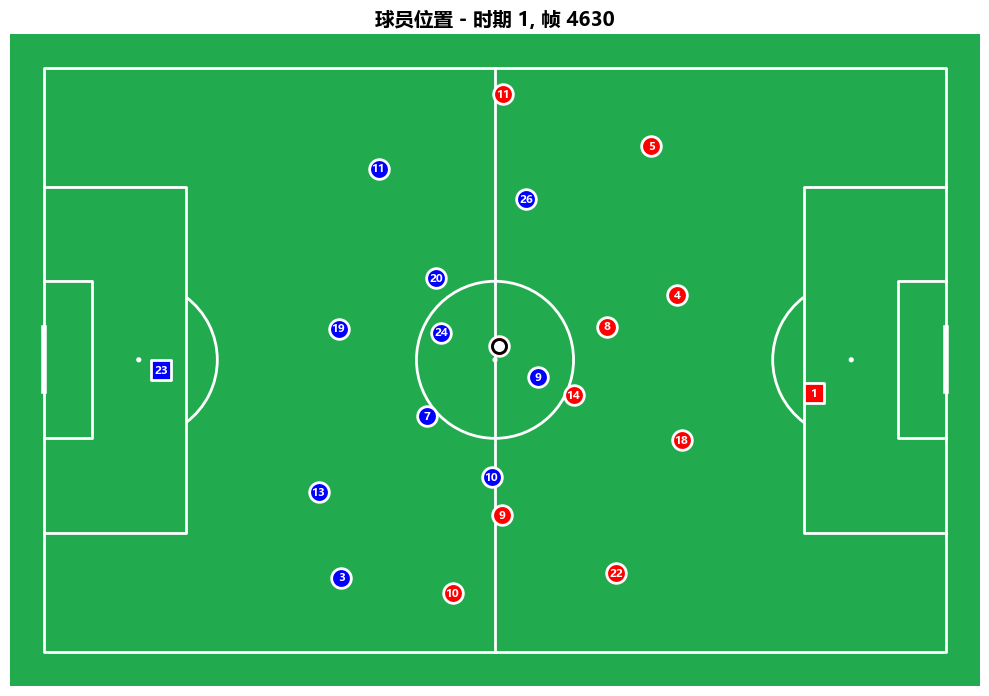


图例:
  🔵 圆形 = 主队球员
  🔴 圆形 = 客队球员
  🔵/🔴 方形 = 守门员
  ⚪ = 球


In [9]:
# 选择第一个时期的某一帧
sample_period = 1
sample_frame_id = dataset.data.filter(pl.col('period_id') == sample_period)['frame_id'].min()

# 获取该帧的数据
frame_data = dataset.data.filter(
    (pl.col('period_id') == sample_period) & 
    (pl.col('frame_id') == sample_frame_id)
).to_pandas()

print(f"绘制时期 {sample_period}, 帧 {sample_frame_id} 的球员位置")
print(f"该帧共有 {len(frame_data)} 个对象（球员+球）")

# 创建球场
pitch = Pitch(
    pitch_type='secondspectrum',
    pitch_length=dataset.settings.pitch_dimensions.pitch_length,
    pitch_width=dataset.settings.pitch_dimensions.pitch_width,
    pitch_color='#22ab4e',
    line_color='white',
    linewidth=2
)

fig, ax = pitch.draw(figsize=(10, 14))

# 绘制球员
for _, row in frame_data.iterrows():
    if row['team_id'] == 'ball':
        # 绘制球
        ax.scatter(row['x'], row['y'], c='white', s=100, edgecolors='black', linewidths=2, zorder=10)
    else:
        # 绘制球员
        player = dataset.get_player_by_id(row['id'])
        color = 'blue' if player.is_home else 'red'
        marker = 's' if player.is_gk else 'o'
        ax.scatter(row['x'], row['y'], c=color, s=200, marker=marker, edgecolors='white', linewidths=2)
        
        # 添加球衣号码
        if player.number:
            ax.text(row['x'], row['y'], str(player.number), 
                   ha='center', va='center', color='white', fontsize=8, weight='bold')

ax.set_title(f'球员位置 - 时期 {sample_period}, 帧 {sample_frame_id}', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n图例:")
print("  🔵 圆形 = 主队球员")
print("  🔴 圆形 = 客队球员")
print("  🔵/🔴 方形 = 守门员")
print("  ⚪ = 球")

## 9. 保存处理后的数据

保存为Parquet格式，这是MORPH项目的标准格式。

In [10]:
# 保存追踪数据
output_file = OUTPUT_DIR / f"tracking_data_{FINAL_GAME_ID}.parquet"

print(f"保存处理后的数据到: {output_file}")
dataset.data.write_parquet(output_file)
print(f"✅ 保存成功！文件大小: {output_file.stat().st_size / 1024 / 1024:.2f} MB")

# 保存元数据信息
metadata_info = {
    'game_id': metadata.game_id,
    'frame_rate': metadata.frame_rate,
    'pitch_length': pitch_dims.pitch_length,
    'pitch_width': pitch_dims.pitch_width,
    'home_team': home_team.name,
    'away_team': away_team.name,
    'n_frames': n_frames,
    'n_players': n_players,
}

metadata_file = OUTPUT_DIR / f"metadata_{FINAL_GAME_ID}.json"
import json
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata_info, f, indent=2, ensure_ascii=False)
print(f"✅ 元数据已保存: {metadata_file}")

保存处理后的数据到: ..\..\data\morph_test\tracking_data_10517.parquet
✅ 保存成功！文件大小: 117.18 MB
✅ 元数据已保存: ..\..\data\morph_test\metadata_10517.json


## 10. 总结

本notebook完成了以下工作：

1. ✅ 成功加载2022世界杯决赛的追踪数据
2. ✅ 转换为MORPH统一格式（Polars DataFrame）
3. ✅ 验证数据质量
4. ✅ 进行基本数据探索
5. ✅ 可视化球员位置
6. ✅ 保存为Parquet格式

### 输出文件

- `tracking_data_10517.parquet`: 追踪数据（Polars格式）
- `metadata_10517.json`: 元数据信息

### 下一步

- 运行 `1.2_test_Contextualization.ipynb` 进行比赛阶段分类
- 运行 `1.3_test_Scaling.ipynb` 进行位置缩放

In [11]:
print("\n" + "=" * 60)
print("数据预处理完成！")
print("=" * 60)
print(f"\n数据集信息:")
print(f"  - 比赛: {home_team.name} vs {away_team.name}")
print(f"  - 总帧数: {n_frames:,}")
print(f"  - 数据行数: {len(dataset.data):,}")
print(f"  - 球员数: {n_players}")
print(f"\n✅ 数据已准备就绪，可以进行后续分析")


数据预处理完成！

数据集信息:
  - 比赛: Argentina vs France
  - 总帧数: 129,368
  - 数据行数: 2,966,182
  - 球员数: 35

✅ 数据已准备就绪，可以进行后续分析
